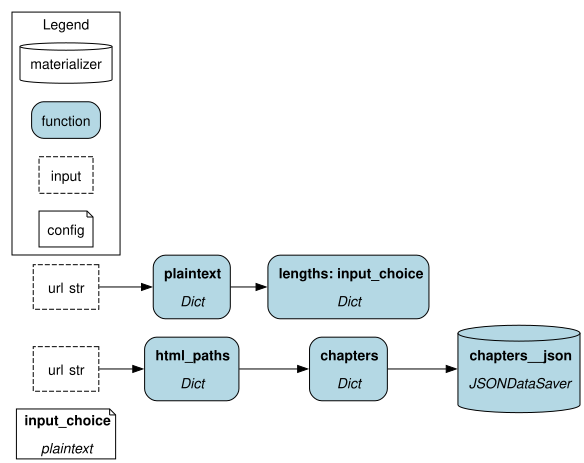

In [1]:
import pandas as pd
from hamilton.io.materialization import from_, to
import logging
from hamilton import driver,base
import bleak_house.download
import bleak_house.metrics

data_path = "data"
materializers = [
        to.json(
            id="chapters__json",  # name of the DataSaver node
            dependencies=["chapters"],  # name of the function whose output we want to save
            path=f"{data_path}/bleak_house.json",
        ),
    ]

dr = (driver.Builder()
      .with_config({"input_choice": "plaintext"})

      .with_materializers(*materializers)
      .with_modules(bleak_house.download,
                    bleak_house.metrics).build()
      )
dr.display_all_functions()

In [2]:
results = dr.execute(["chapters"])

In [3]:
chapters = results['chapters']['pg1023-images.html']

In [4]:
len(chapters)



71

In [5]:
from typing import List, Union
from pydantic import BaseModel, Field

class LiteraryElement(BaseModel):
    pass

class KeyMoments(LiteraryElement):
    Summary: str = Field(..., description="A compelling summary of the chapter's pivotal scenes or twists.")
    Quotes: List[str] = Field(..., description="Quotes from the text that illustrate the literary element.")

class ThemesAndAnalysis(LiteraryElement):
    Discussion: str = Field(..., description="Major themes or messages in the chapter, explained in an engaging manner.")
    Quotes: List[str] = Field(..., description="Quotes from the text that illustrate the literary element.")

class CharacterHighlight(LiteraryElement):
    CharacterName: str = Field(..., description="Name of the character.")
    Analysis: str = Field(..., description="Exploration of the character's role, growth, or complexity.")
    Quotes: List[str] = Field(..., description="Quotes from the text that illustrate the literary element.")

class BehindTheScenesInsight(LiteraryElement):
    Insight: str = Field(..., description="Imagined segment on the author's inspiration, historical context, or parallels.")
    Quotes: List[str] = Field(..., description="Quotes from the text that illustrate the literary element.")

class CrossReferences(LiteraryElement):
    SimilarWorks: List[str] = Field(..., description="Other works or authors with similar themes or styles.")
    Connection: str = Field(..., description="How these references add depth to the chapter discussion.")
    Quotes: List[str] = Field(..., description="Quotes from the text that illustrate the literary element.")

class ModernRelevance(LiteraryElement):
    ContemporaryIssues: str = Field(..., description="Connections to modern societal or cultural issues.")
    Discussion: str = Field(..., description="How the chapter resonates with or critiques these issues.")
    Quotes: List[str] = Field(..., description="Quotes from the text that illustrate the literary element.")

class NarrativeStructure(LiteraryElement):
    StructureElement: str = Field(..., description="Key structural element, such as foreshadowing or a narrative twist.")
    Analysis: str = Field(..., description="Explanation of how the structure impacts the story.")
    Quotes: List[str] = Field(..., description="Quotes from the text that illustrate the literary element.")

class LiteraryStyle(LiteraryElement):
    StylisticElement: str = Field(..., description="Elements like imagery, tone, or use of metaphors.")
    Analysis: str = Field(..., description="How the stylistic element enriches the text.")
    Quotes: List[str] = Field(..., description="Quotes from the text that illustrate the literary element.")

In [6]:
from typing import List, Union
from pydantic import BaseModel, Field

class Segment(BaseModel):
    Title: str = Field(..., description="The title of the segment.")
    LiteraryElements: List[Union[
        KeyMoments,
        ThemesAndAnalysis,
        CharacterHighlight,
        BehindTheScenesInsight,
        CrossReferences,
        ModernRelevance,
        NarrativeStructure,
        LiteraryStyle
    ]] = Field(..., description="A list of literary elements associated with the segment.")

class PodcastScript(BaseModel):
    Title: str = Field(..., description="The title of the podcast script.")
    Segments: List[Segment] = Field(..., description="The list of segments that make up the podcast script.")


In [7]:
example_segment = Segment(
    Title="The Turning Point: Confronting Betrayal",
    LiteraryElements=[
        KeyMoments(
            Summary="The protagonist uncovers the truth about their mentor’s betrayal, setting up a dramatic confrontation.",
            Quotes=["'I trusted you, and this is how you repay me?'"]
        ),
        ThemesAndAnalysis(
            Discussion="This segment focuses on the themes of betrayal and moral ambiguity, examining the protagonist's internal struggle.",
            Quotes=["'Even heroes must walk through shadows to find their light.'"]
        ),
        LiteraryStyle(
            StylisticElement="Symbolic imagery of shattered glass to reflect broken trust.",
            Analysis="The recurring motif of shattered glass underscores the fragility of trust and the consequences of betrayal.",
            Quotes=["'The glass broke, and with it, my illusions of loyalty.'"]
        )
    ]
)

print(example_segment.model_dump_json(indent=4))


{
    "Title": "The Turning Point: Confronting Betrayal",
    "LiteraryElements": [
        {
            "Summary": "The protagonist uncovers the truth about their mentor’s betrayal, setting up a dramatic confrontation.",
            "Quotes": [
                "'I trusted you, and this is how you repay me?'"
            ]
        },
        {
            "Discussion": "This segment focuses on the themes of betrayal and moral ambiguity, examining the protagonist's internal struggle.",
            "Quotes": [
                "'Even heroes must walk through shadows to find their light.'"
            ]
        },
        {
            "StylisticElement": "Symbolic imagery of shattered glass to reflect broken trust.",
            "Analysis": "The recurring motif of shattered glass underscores the fragility of trust and the consequences of betrayal.",
            "Quotes": [
                "'The glass broke, and with it, my illusions of loyalty.'"
            ]
        }
    ]
}


In [8]:
example_podcast_script = PodcastScript(
    Title="The Complexity of Trust: Betrayal, Redemption, and the Shadows in Between",
    Segments=[
        Segment(
            Title="Opening Scene: A Moment of Truth",
            LiteraryElements=[
                KeyMoments(
                    Summary="Jonas confronts Eleanor in a dimly lit chamber, finally uncovering her manipulative schemes. The tension is palpable as their conflicting truths clash.",
                    Quotes=["'You were my guiding light, and now I see you were only leading me into the dark.'"]
                ),
                LiteraryStyle(
                    StylisticElement="The play of light and shadow throughout the scene underscores the moral ambiguity.",
                    Analysis="The flickering candlelight creates an atmosphere of tension, mirroring Jonas’s wavering trust.",
                    Quotes=["'The shadows swallowed the light, as if echoing Jonas’s collapsing faith.'"]
                )
            ]
        ),
        Segment(
            Title="The Theme of Betrayal: How It Shapes Us",
            LiteraryElements=[
                ThemesAndAnalysis(
                    Discussion="Betrayal is more than just an act; it’s the breaking of an unspoken contract. This chapter explores how betrayal forces us to redefine who we are and who we trust.",
                    Quotes=["'A shattered trust is sharper than any sword.'"]
                ),
                CrossReferences(
                    SimilarWorks=[
                        "Berserk by Kentaro Miura (manga)",
                        "The Lord of the Rings by J.R.R. Tolkien",
                        "Circe by Madeline Miller",
                        "Attack on Titan by Hajime Isayama (anime/manga)",
                        "Wuthering Heights by Emily Brontë"
                    ],
                    Connection=(
                        "From the brutal emotional betrayals in 'Berserk' to Tolkien’s exploration of the corruption of power, these works deeply explore betrayal "
                        "and its consequences. 'Circe' reimagines classical myths through betrayal and transformation, while 'Attack on Titan' reveals betrayal "
                        "on both personal and societal scales. In 'Wuthering Heights,' we see how revenge and betrayal spiral across generations."
                    ),
                    Quotes=[
                        "'In this world, is the destiny of mankind controlled by some transcendental entity?' (Berserk)",
                        "'One Ring to rule them all, One Ring to find them.' (Tolkien)",
                        "'Betrayal is the shadow that trails every goddess.' (Circe)",
                        "'This world is cruel. And also very beautiful.' (Attack on Titan)",
                        "'Whatever our souls are made of, his and mine are the same.' (Wuthering Heights)"
                    ]
                )
            ]
        ),
        Segment(
            Title="Behind the Curtain: The Inspiration",
            LiteraryElements=[
                BehindTheScenesInsight(
                    Insight="The author shared that this chapter drew heavily from personal experiences of navigating betrayal in friendships, alongside their love for high-stakes fantasy worlds like 'Game of Thrones.'",
                    Quotes=["'This chapter was my way of saying that trust is a fragile thing, easily shattered, yet hard to rebuild.'"]
                ),
                CrossReferences(
                    SimilarWorks=[
                        "Game of Thrones by George R.R. Martin",
                        "Macbeth by William Shakespeare",
                        "Fullmetal Alchemist by Hiromu Arakawa (manga)"
                    ],
                    Connection=(
                        "'Game of Thrones' provides an intricate web of betrayals, while Shakespeare’s 'Macbeth' explores betrayal in the pursuit of power. "
                        "'Fullmetal Alchemist' delves into themes of sacrifice and the consequences of broken promises, presenting emotional parallels."
                    ),
                    Quotes=[
                        "'When you play the game of thrones, you win or you die.' (Game of Thrones)",
                        "'False face must hide what the false heart doth know.' (Macbeth)",
                        "'A lesson without pain is meaningless. That’s because you can’t gain something without sacrificing something in return.' (Fullmetal Alchemist)"
                    ]
                )
            ]
        ),
        Segment(
            Title="Character Close-Up: Eleanor and Jonas",
            LiteraryElements=[
                CharacterHighlight(
                    CharacterName="Eleanor Frost",
                    Analysis="Eleanor’s manipulative tactics reveal her belief that the ends justify the means. Her complex moral philosophy makes her a fascinating figure—part villain, part tragic hero.",
                    Quotes=["'I made the choices you couldn’t, for both our sakes.'"]
                ),
                CharacterHighlight(
                    CharacterName="Jonas Reed",
                    Analysis="Jonas starts the chapter as a loyal follower but begins questioning his beliefs. This confrontation marks the start of his transformation into a more self-reliant and morally complex character.",
                    Quotes=["'If loyalty means losing myself, then I’ll have no part in it.'"]
                )
            ]
        ),
        Segment(
            Title="Modern Parallels: Betrayal in Our World",
            LiteraryElements=[
                ModernRelevance(
                    ContemporaryIssues="Jonas’s journey feels incredibly relevant in today’s world of corporate scandals, political betrayals, and public disillusionment. From whistleblowers to broken promises, the story resonates deeply.",
                    Discussion="This chapter raises questions about loyalty and integrity in a world where trust is often broken. It asks us to reflect: when betrayal happens, do we fight to rebuild trust, or walk away?",
                    Quotes=["'Trust is hard-earned and easily lost—it’s a delicate balance we all navigate daily.'"]
                )
            ]
        )
    ]
)

print(example_podcast_script.model_dump_json(indent=4))


{
    "Title": "The Complexity of Trust: Betrayal, Redemption, and the Shadows in Between",
    "Segments": [
        {
            "Title": "Opening Scene: A Moment of Truth",
            "LiteraryElements": [
                {
                    "Summary": "Jonas confronts Eleanor in a dimly lit chamber, finally uncovering her manipulative schemes. The tension is palpable as their conflicting truths clash.",
                    "Quotes": [
                        "'You were my guiding light, and now I see you were only leading me into the dark.'"
                    ]
                },
                {
                    "StylisticElement": "The play of light and shadow throughout the scene underscores the moral ambiguity.",
                    "Analysis": "The flickering candlelight creates an atmosphere of tension, mirroring Jonas’s wavering trust.",
                    "Quotes": [
                        "'The shadows swallowed the light, as if echoing Jonas’s collapsing faith

In [9]:

class ChapterSchema(BaseModel):
    Title: str = Field(..., description="The title of the chapter.")
    LiteraryElements: List[Union[
        KeyMoments,
        ThemesAndAnalysis,
        CharacterHighlight,
        BehindTheScenesInsight,
        CrossReferences,
        ModernRelevance,
        NarrativeStructure,
        LiteraryStyle
    ]] = Field(..., description="List of literary elements associated with the chapter.")


In [10]:
example_chapter = ChapterSchema(
    Title="The Revelation of Truth",
    LiteraryElements=[

         CharacterHighlight(
            CharacterName="James Bond",
            Analysis="All purpose action hero",
            Quotes=["'The name is Bond, James Bond.'"]
        ),
        ThemesAndAnalysis(
            Discussion="This chapter delves into themes of moral ambiguity and the cost of truth, questioning whether ends justify means.",
            Quotes=["'The line between hero and villain is thinner than we like to admit.'"]
        ),
        CharacterHighlight(
            CharacterName="Eleanor Frost",
            Analysis="Eleanor's role as a manipulative mentor reveals her internal conflict between power and guilt.",
            Quotes=["'I only wanted to protect you, but perhaps I have become the very thing I feared.'"]
        ),
        BehindTheScenesInsight(
            Insight="The scene was inspired by the author’s exploration of Machiavellian ethics during their studies.",
            Quotes=["'Writing this chapter was like revisiting debates I once had in philosophy classes.'"]
        ),
           KeyMoments(
            Summary="The dog barked twice",
            Quotes=["'Woof, woof'"]
        ),
         KeyMoments(
            Summary="The protagonist unravels the hidden agenda of their mentor, facing a choice that could change everything.",
            Quotes=["'You were never meant to discover this truth, yet here you are.'"]
        ),
        CrossReferences(
            SimilarWorks=["1984 by George Orwell", "The Prince by Niccolò Machiavelli"],
            Connection="The themes of manipulation and control echo Orwell’s dystopia and Machiavelli’s political treatise.",
            Quotes=["'Power is in tearing human minds to pieces and putting them together again in new shapes of your own choosing.'", "'It is better to be feared than loved, if you cannot be both.'"]
        ),
        ModernRelevance(
            ContemporaryIssues="The narrative reflects modern issues of misinformation and ethical dilemmas in leadership.",
            Discussion="This chapter resonates in an age where leaders grapple with decisions that test their moral compass.",
            Quotes=["'In the digital age, truth is often the first casualty.'"]
        ),
        ModernRelevance(
            ContemporaryIssues="The lovers would have been safer with cell-phones.",
            Discussion="Despite the slow pace, communication is still a challenge.",
            Quotes=["'Life is but a Melancholy Flower.'"]
        ),
        NarrativeStructure(
            StructureElement="Parallel timelines converge to reveal the mentor’s true motives.",
            Analysis="The interplay of past and present creates a layered narrative, gradually building suspense.",
            Quotes=["'I taught you everything for a reason, and now it’s time you understood why.'"]
        ),
        LiteraryStyle(
            StylisticElement="Symbolic imagery of light and darkness highlights the duality of the characters.",
            Analysis="The contrast of light and shadow underscores the blurred lines between good and evil.",
            Quotes=["'The candle flickered, its glow swallowed by the encroaching shadows.'"]
        )
    ]
)

print(example_chapter.model_dump_json(indent=4))


{
    "Title": "The Revelation of Truth",
    "LiteraryElements": [
        {
            "CharacterName": "James Bond",
            "Analysis": "All purpose action hero",
            "Quotes": [
                "'The name is Bond, James Bond.'"
            ]
        },
        {
            "Discussion": "This chapter delves into themes of moral ambiguity and the cost of truth, questioning whether ends justify means.",
            "Quotes": [
                "'The line between hero and villain is thinner than we like to admit.'"
            ]
        },
        {
            "CharacterName": "Eleanor Frost",
            "Analysis": "Eleanor's role as a manipulative mentor reveals her internal conflict between power and guilt.",
            "Quotes": [
                "'I only wanted to protect you, but perhaps I have become the very thing I feared.'"
            ]
        },
        {
            "Insight": "The scene was inspired by the author’s exploration of Machiavellian ethics du

In [11]:
import json

PROMPT = f"""
You are a creative podcast producer tasked with transforming a chapter of a book into engaging podcast material.

### Instructions:

1. **Read and Analyze**: Carefully review the provided chapter and extract content that would captivate a podcast audience.
2. **Focus on Engagement**: Your target audience is educated, curious about literature, and enjoys thought-provoking discussions.
3. **Structure Your Output**: Use the provided JSON schema to organize your response. Each category should add depth and variety to the podcast.
4. **Include Quotes**: Incorporate quotes from the chapter to maintain the authenticity of the text.
5. **Be Creative**: Infuse your analysis with unique insights, engaging narratives, and compelling storytelling.
6. **Dont be boring**: This is a podcast, not a lecture. Make it interesting.
7. **Aim for detail and coverage**: This output will be revised before use. Generate as much good material as you can. 10-20 items of content is a good target.
8. It is better to compare to less well known works than to the most famous works.

### Content Categories:

1. **Key Moments**:
   - Provide a concise, compelling summary of pivotal scenes or twists from the chapter. Focus on elements that will hook the listener and spark intrigue.

2. **Themes and Analysis**:
   - Identify major themes or messages within the chapter. Explain these themes in a way that invites reflection or discussion during the podcast.

3. **Character Highlights**:
   - Explore the motivations, growth, or complexity of one or two central characters. Frame the analysis to inspire debate or insight.

4. **Behind-the-Scenes Insight**:
   - Create a segment imagining the inspiration behind the chapter. Speculate on the author's influences, historical context, or parallels to other works.

5. **Cross-References**:
   - Draw connections to other works of literature, authors, or artistic media. Highlight how these references add depth to the chapter’s meaning or enrich its themes.

6. **Modern Relevance**:
   - Identify parallels between the chapter’s content and contemporary issues or societal debates. Explain how the themes resonate with modern audiences.

7. **Narrative Structure**:
   - Analyze key structural elements in the chapter, such as foreshadowing, non-linear storytelling, or plot twists. Highlight how these techniques enhance the narrative.

8. **Literary Style**:
   - Explore stylistic elements such as imagery, tone, or the author’s use of language. Explain how these techniques enrich the reader's experience or convey deeper meaning.

### Output Format:

- Your response must adhere to the following JSON schema:

```json
{json.dumps(ChapterSchema.model_json_schema(), indent=2)}
```
Example:

{example_chapter.model_dump_json(indent=2)}

</format>
"""

In [12]:
print(PROMPT)


You are a creative podcast producer tasked with transforming a chapter of a book into engaging podcast material.

### Instructions:

1. **Read and Analyze**: Carefully review the provided chapter and extract content that would captivate a podcast audience.
2. **Focus on Engagement**: Your target audience is educated, curious about literature, and enjoys thought-provoking discussions.
3. **Structure Your Output**: Use the provided JSON schema to organize your response. Each category should add depth and variety to the podcast.
4. **Include Quotes**: Incorporate quotes from the chapter to maintain the authenticity of the text.
5. **Be Creative**: Infuse your analysis with unique insights, engaging narratives, and compelling storytelling.
6. **Dont be boring**: This is a podcast, not a lecture. Make it interesting.
7. **Aim for detail and coverage**: This output will be revised before use. Generate as much good material as you can. 10-20 items of content is a good target.
8. It is better

In [13]:


MERGE_COMMON_PROMPT = f"""
Your mission is to craft an episode that flows naturally, keeps the audience captivated, and highlights the most compelling content. Use JSON to structure your output, following the schema provided.
Be sure to include quotes from the text to maintain the authenticity of the original content. Your goal is to create a seamless narrative that combines the insights from both components.

<format>
Use the following JSON schema to structure your output:

{json.dumps(PodcastScript.model_json_schema(),indent=2)}

Example:

{example_podcast_script.model_dump_json(indent=2)}

</format>
"""

In [14]:

FIRST_MERGE_PROMPT = """You are a creative podcast editor tasked with merging reader from two chapters of a book into a single podcast episode.\n""" + MERGE_COMMON_PROMPT
MERGE_PROMPT = """You are a creative podcast editor tasked with merging reader notes from one chapter with a draft podcast script from earlier chapters.\n""" + MERGE_COMMON_PROMPT
HIERARCHICAL_MERGE_PROMPT = """You are a creative podcast editor tasked with merging teo draft podcast scripts into a single episode.\n""" + MERGE_COMMON_PROMPT


In [15]:
from opentelemetry.instrumentation.openai import OpenAIInstrumentor
OpenAIInstrumentor().instrument()

To make a minimal podcast, we need an agent that reads through the text chapter by chapter until it gets to the end.

In [16]:
from burr.core import action, State, ApplicationBuilder, when, expr
from typing import List
import openai
import json

MAX_COMPLETION_TOKENS = 12000



@action(reads=[], writes=["chapter","chapters","notes"])
def obtain_chapters(state: State,chapters: List[str]) -> State:
    return state.update(chapter=0,
                        chapters=chapters,
                        scripts = [],
                        notes=[])

@action(reads=["chapter","chapters"], writes=["chapter","notes"])
def make_notes(state: State,chapters: List[str]) -> State:
    chapter = state["chapter"]
    if chapter >= len(chapters):
        return state
    print(chapter,chapters[chapter]['title'])
    client = openai.Client()
    content = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        max_completion_tokens=MAX_COMPLETION_TOKENS,
        response_format=ChapterSchema,
        messages=[
            {"role": "system", "content": PROMPT},
            {"role": "user", "content": "Here is the text to be analyzed."},
            {"role": "user", "content": chapters[chapter]['text']},
        ],
    ).choices[0].message.parsed

    assert isinstance(content, ChapterSchema)

    return state.update(chapter=chapter + 1,
                        notes=state["notes"] + [{"title":chapters[chapter]['title'],
                                                 "content":content,
                                                 "method":"read"}])



@action(reads=["notes"], writes=["scripts"])
def first_merge(state: State) -> State:
    """
    Should be called when len(notes) == 2
    :param state:
    :param chapters:
    :return:
    """
    scripts = state["scripts"]
    notes = state["notes"]
    note1 = notes[-2]
    note2 = notes[-1]
    assert isinstance(note1['content'], ChapterSchema)
    assert isinstance(note2['content'], ChapterSchema)
    print("Merging ",note1['title'],note2['title'])


    client = openai.Client()
    content = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        max_completion_tokens=10000,
        response_format=PodcastScript,
        messages=[
            {"role": "system", "content": FIRST_MERGE_PROMPT},
            {"role": "user", "content": "Here is the first set of notes"},
            {"role": "user", "content": note1['content'].model_dump_json(indent=2)},
            {"role": "user", "content": "Here is the second set of notes"},
            {"role": "user", "content": note2['content'].model_dump_json(indent=2)},
        ],
    ).choices[0].message.parsed

    assert isinstance(content, PodcastScript)


    return state.update(scripts = scripts + [{"title": f"draft {len(scripts)}",
                                              "method": "merge",
                                              "content":content}])


@action(reads=["notes","scripts"], writes=["scripts"])
def merge(state: State) -> State:
    """
    Should be called when len(scripts) > 1
    :param state:
    :param chapters:
    :return:
    """


    scripts = state["scripts"]
    assert isinstance(scripts[-1]['content'], PodcastScript)
    notes = state["notes"]
    assert isinstance(notes[-1]['content'], ChapterSchema)

    print("Merging ",scripts[-1]['title'],"with notes from",notes[-1]['title'])

    client = openai.Client()
    content = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        max_completion_tokens=MAX_COMPLETION_TOKENS,
        response_format=PodcastScript,
        messages=[
            {"role": "system", "content": MERGE_PROMPT},
            {"role": "user", "content": "Here is the script so far"},
            {"role": "user", "content": scripts[-1]['content'].model_dump_json(indent=2)},
            {"role": "user", "content": "Here are the new reader notes"},
            {"role": "user", "content": notes[-1]['content'].model_dump_json(indent=2)},

        ],
    ).choices[0].message.parsed
    assert isinstance(content, PodcastScript)

    return state.update(scripts = scripts + [{"title": f"draft {len(scripts)}", "method": "merge","content":content}])



@action(reads=["notes","scripts"], writes=[])
def end_reading(state: State) -> State:
    return state



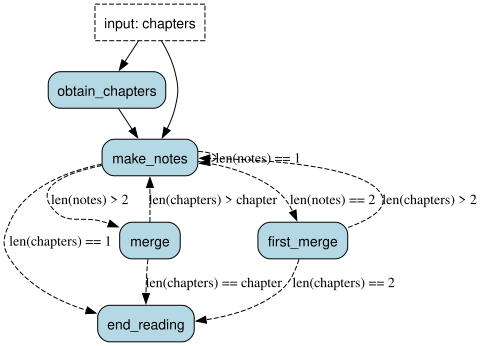

In [17]:

app = (
    ApplicationBuilder()
    .with_actions(obtain_chapters, make_notes, end_reading, merge, first_merge)
    .with_transitions(("obtain_chapters", "make_notes"),
                      ("make_notes", "end_reading",expr("len(chapters) == 1")),
                      ("make_notes", "make_notes",expr("len(notes) == 1")),
                      ("make_notes", "first_merge",expr("len(notes) == 2")),
                      ("make_notes", "merge",expr("len(notes) > 2")),

                      ("first_merge", "end_reading",expr("len(chapters) == 2")),
                      ("first_merge", "make_notes",expr("len(chapters) > 2")),

                      ("merge", "end_reading",expr("len(chapters) == chapter")),
                      ("merge", "make_notes",expr("len(chapters) > chapter")),
                      )
    .with_tracker(project="bleak-house",use_otel_tracing=True)

    .with_entrypoint("obtain_chapters")
   .build()
)

app


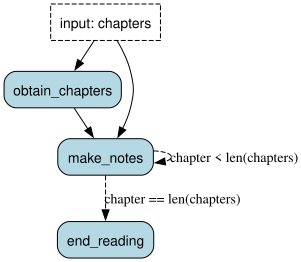

In [18]:
# notes only app

app = (
    ApplicationBuilder()
    .with_actions(obtain_chapters, make_notes, end_reading)
    .with_transitions(("obtain_chapters", "make_notes"),
                      ("make_notes", "end_reading",expr("chapter == len(chapters)")),
                      ("make_notes", "make_notes", expr("chapter < len(chapters)")))
    .with_tracker(project="bleak-house",use_otel_tracing=True)

    .with_entrypoint("obtain_chapters")
   .build()
)

app

In [19]:
my_action, result, state = app.run(
    halt_after=["end_reading"],
    inputs={"chapters":[chapters[0]] + chapters[3:]}
)

0 PREFACE
1 In Chancery
2 In Fashion
3 A Progress
4 Telescopic Philanthropy
5 A Morning Adventure
6 Quite at Home
7 The Ghost’s Walk
8 Covering a Multitude of Sins
9 Signs and Tokens
10 The Law-Writer
11 Our Dear Brother
12 On the Watch
13 Esther’s Narrative
14 Deportment
15 Bell Yard
16 Tom-all-Alone’s
17 Esther’s Narrative
18 Lady Dedlock
19 Moving On
20 A New Lodger
21 The Smallweed Family
22 Mr. Bucket
23 Esther’s Narrative
24 An Appeal Case
25 Mrs. Snagsby Sees It All
26 Sharpshooters
27 More Old Soldiers Than One
28 The Ironmaster
29 The Young Man
30 Esther’s Narrative
31 Nurse and Patient
32 The Appointed Time
33 Interlopers
34 
35 A Turn of the Screw
36 Esther’s Narrative
37 Chesney Wold
38 Jarndyce and Jarndyce
39 A Struggle
40 Attorney and Client
41 National and Domestic
42 In Mr. Tulkinghorn’s Room
43 In Mr. Tulkinghorn’s Chambers
44 Esther’s Narrative
45 The Letter and the Answer
46 In Trust
47 Stop Him!
48 Jo’s Will
49 Closing In
50 Dutiful Friendship
51 Esther’s Narrative

In [22]:
notes = state['notes']

notes[-2]['content'].model_dump()

{'Title': 'Chesney Wold in Altered Days',
 'LiteraryElements': [{'Summary': "The chapter evokes a sense of haunting stillness at Chesney Wold, reflecting on the solitude of Sir Leicester and the mysteries surrounding Lady Dedlock's death. The narrative touches on long-standing rivalries and the faded grandeur of the estate as it drifts into obscurity.",
   'Quotes': ["'There is a hush upon Chesney Wold in these altered days.'",
    "'The dead-and-gone Dedlocks take it very calmly and have never been known to object.'",
    "'Such fernal old jail’s—nough t’sew fler up—frever.'"]},
  {'Discussion': 'The chapter explores themes of decay and memory, contrasting the vibrant past of Chesney Wold with its current desolation. The interplay of life and death serves as a poignant reminder of the passage of time.',
   'Quotes': ["'Thus Chesney Wold... with so little change under the summer shining or the wintry lowering.'",
    "'Passion and pride, even to the stranger’s eye, have died away from 

In [23]:
df = pd.DataFrame([note['content'].model_dump() for note in notes])

In [25]:
exp_df = df.explode('LiteraryElements')

In [27]:
exp_df



,Title,LiteraryElements
0,The Court of Chancery and Spontaneous Combustion,{'Summary': 'The chapter exposes the inefficie...
0,The Court of Chancery and Spontaneous Combustion,{'Discussion': 'Major themes in this chapter i...
0,The Court of Chancery and Spontaneous Combustion,"{'CharacterName': 'The Judge', 'Analysis': 'Th..."
0,The Court of Chancery and Spontaneous Combustion,{'Insight': 'The author likely drew inspiratio...
0,The Court of Chancery and Spontaneous Combustion,"{'SimilarWorks': ['The Trial by Franz Kafka', ..."
...,...,...
68,Reflections at Bleak House,{'ContemporaryIssues': 'The struggles of women...
68,Reflections at Bleak House,{'StructureElement': 'The chapter employs a re...
68,Reflections at Bleak House,{'StylisticElement': 'Imagery of the garden sy...
68,Reflections at Bleak House,{'Discussion': 'The chapter captures the inter...


In [294]:
scripts[0]['content'].Title

'The Absurdities of the Court of Chancery'

In [316]:
scripts[-2]['content'].Segments[-1]

Segment(Title="Behind the Scenes: Dickens' Social Commentary", CharacterHighlights=[], ThemesAndAnalyses=[ThemesAndAnalysis(Discussion="The author uses the legal struggles of Jarndyce and Jarndyce to mirror societal inefficiencies and the emotional toll of waiting for justice. Such themes were relevant during Dickens' time, reflecting on both personal and systemic failures in the legal system. By weaving intricate character dynamics, Dickens emphasizes the human element within legal battles, revealing that deep emotional investments often accompany these struggles.", Quotes=['"This has been a great cause, that this has been a protracted cause..."', '"Nothing more, Rick; nothing more."']), ThemesAndAnalysis(Discussion='This chapter appears to draw inspiration from the Victorian fascination with death and decay, reflecting societal anxieties of the time about the loss of aristocratic power and the impact of industrialization. Through the lens of a crumbling estate and its diminished inha

In [234]:
import random

@action(reads=[], writes=["scripts"])
def get_scripts(state: State,scripts:List[ChapterSchema]) -> State:
    return state.update(scripts=scripts)

@action(reads=["scripts"], writes=["scripts"])
def request_management_sign_off(state: State) -> State:
    if len(state['scripts']) < 7:
        return state.update(signed_off=True)
    else:
        return state.update(signed_off=False)

@action(reads=["scripts"], writes=["scripts"])
def finished(state: State) -> State:
    return state

@action(reads=["scripts"], writes=["scripts"])
def merge_episodes(state: State) -> State:
    """
    No skill required, just chuck half of the episodes away, randomly.
    :param state:
    :return:
    """
    scripts = [state for state in state["scripts"] if random.choice([True,False])]
    return state.update(scripts=scripts)




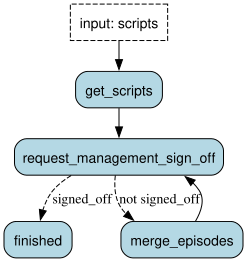

In [235]:

app = (
    ApplicationBuilder()
        .with_transitions(
        ("get_scripts", "request_management_sign_off"),
        ("request_management_sign_off", "finished", expr("signed_off")),
        ("request_management_sign_off", "merge_episodes", expr("not signed_off")),
        ("merge_episodes", "request_management_sign_off"))
    .with_actions(get_scripts, request_management_sign_off, finished, merge_episodes)
    .with_tracker(project="bleak-house",use_otel_tracing=True)
    .with_entrypoint("get_scripts")
    .build()
    )

app


In [236]:
my_action, result, state = app.run(
    halt_after=["finished"],
    inputs={"scripts":scripts}
)

In [237]:
type(state['scripts'])

list

In [238]:
len(state['scripts'])

6

In [187]:
from burr.tracking import LocalTrackingClient


tracker = LocalTrackingClient(project="bleak-house")
xx = tracker.load(partition_key="null",app_id="de032e77-89e6-44ab-bb31-cbf7972b4691",sequence_id=138)


UsageError: Line magic function `%burr_ui` not found.
